<a href="https://colab.research.google.com/github/celinaLind/AI-flashcards/blob/main/AI_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pandas is an analysis library used to process datasets
import pandas as pd
# matplot plotting library used to visualize our data
import matplotlib.pyplot as plt
# seaborn is a visualization library used for more details visuals of our data
import seaborn as sns

In [ ]:
# df for data frame
# use pandas to load in the data set
df = pd.read_csv("churn.csv")

In [ ]:
# show the data
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
# it is important to understand the distribution of data and what information
# is being provided
# to do that we will list out a summary using the describe function
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# next it is beneficial to VISUALIZE the data so you can see any relationships
# between the features
# setting a plotting style using seaborn
sns.set_style(style='whitegrid')
# create new figure with matplot
plt.figure(figsize=(12,10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Churn')

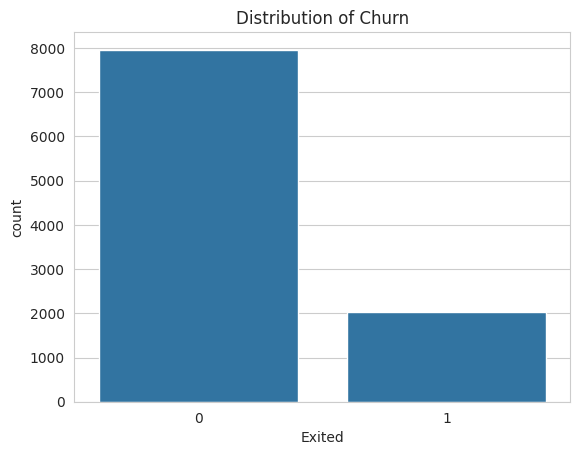

In [ ]:
# create multiple plots to gain a better understanding of your data
# plot the users that have churned
sns.countplot(x="Exited", data=df)
plt.title("Distribution of Churn")

The plot below shows two distinct age groups, as well as four elevated age groups.

Text(0.5, 1.0, 'Age Distribution')

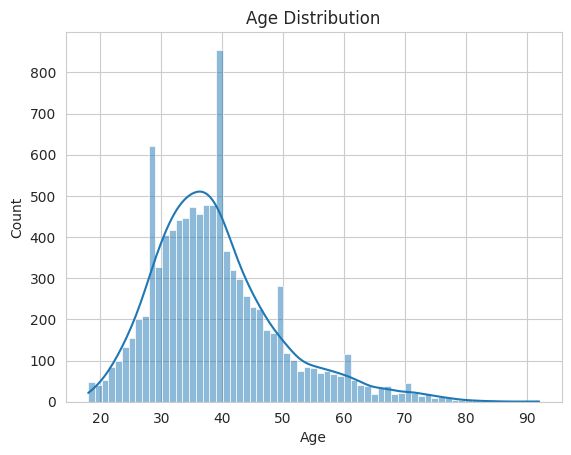

In [ ]:
# Next plot a Histogram of customer ages
# histplot(data used, x values, kernel density estimate[kde])
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution")

Text(0.5, 1.0, 'Credit Score vs Age')

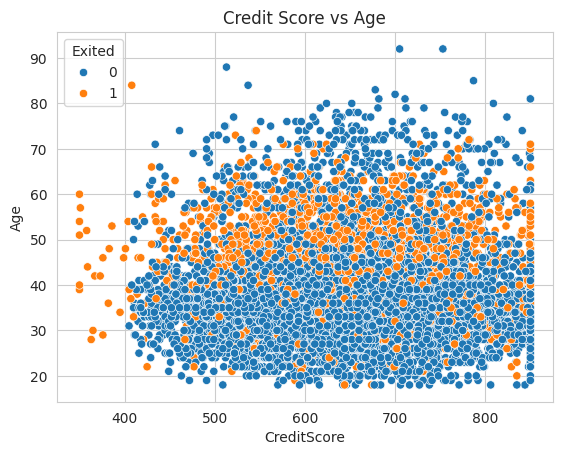

In [ ]:
# Next we will plot credit score vs age vs if user churned
# scatterplot(dataset used, x values, y values, hue defined by if user churned)
sns.scatterplot(data=df, x="CreditScore", y="Age", hue="Exited")
plt.title("Credit Score vs Age")

Based on the plot seen above, customers who are older are more likely to churn than customer who are younger.

Text(0.5, 1.0, 'Balance Distribution by Churn')

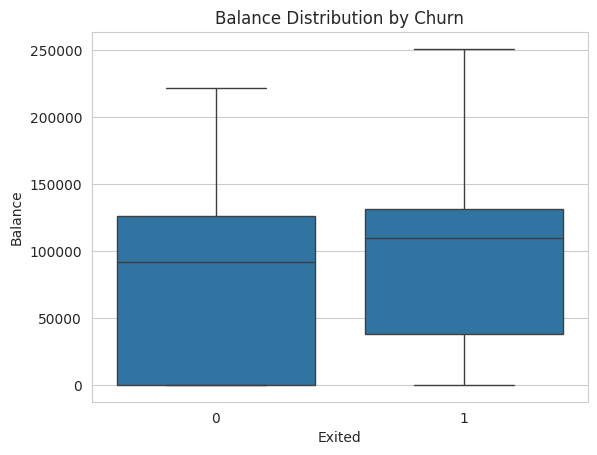

In [ ]:
# Next box plot of acct balance vs churn
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance Distribution by Churn")

The data shows that on average the customers who decide to churn have a higher account balance than those who don't.

*   Line in the box = median  
*   Top line of box = 75 percentile
*   Line at very top = max
*   Line at very bottom = min



median the line at the top of the box shows the 75 percentile

Text(0.5, 1.0, 'Credit Score Distributions by Churn')

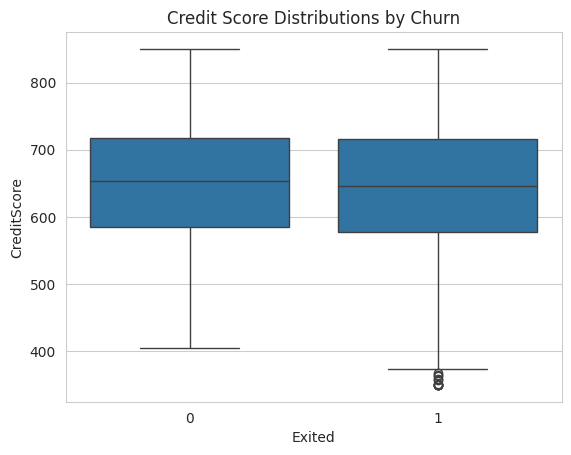

In [ ]:
# comparison of credit score vs churn
sns.boxplot(x="Exited", y="CreditScore", data=df)
plt.title("Credit Score Distributions by Churn")

Not much of a difference, but those who don't churn on average have a higher credit score.

In [ ]:
# BEFORE training the models we need to preprocess the data


**STEP ONE**  
Separate the features (credit score, age, etc.) and the target variable (churn)



In [ ]:
# remove 'Exited' from data frame and save remaining data in features variable
# axis = 1 because we are dropping a column not a row
features = df.drop("Exited", axis=1)

In [ ]:
# holds all of the feature data w/o the "Exited" column
features

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [ ]:
# save "Exited" data to target variable
target = df["Exited"]

In [ ]:
target

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


**STEP TWO**

Remove unnecessary features from the features Dataset
(Ex. rowNumber, surname, etc.)

In [ ]:
features = features.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [ ]:
features

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


**STEP THREE**

Handle missing values
--> drop any rows in the data frame that have missing values

In [ ]:
features = features.dropna()

In [ ]:
features

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


**STEP FOUR**

Convert categorical variable to numerical

--> will change categories such as the Geography and Gender column values to Binary values

> this is done because ML does not understand text and only computes numerical values

In [ ]:
features = pd.get_dummies(features, columns=["Geography", "Gender"])

In [ ]:
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True


>New columns were created for each potential value of the Geography and Gender columns

>then the value True/False (binary 1 or 0) is provided for each customer in each new column

**For each Dataset you will:**

> Train with 80% of the data
> Test with the remaining 20%

*Test and evaluate with different variations to see what results with the highest accuracy*

The model will LEARN on the *training data* which is a subset of all the data

While the model will test its performance on the *smaller testing subset*

In [ ]:
# break up dataset into smaller subsets for training and testing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# random_state allows for reproducable code/results
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [ ]:
# scale the features
# make sure all features contribute equally to the model
# this negates larger number values from skewing the models learning predictions
# keeps from unnecessary bias and learning results

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# show first customer data and compare values and differences
X_train[0]

array([ 0.35649971, -0.6557859 ,  0.34567966, -1.21847056,  0.80843615,
        0.64920267,  0.97481699,  1.36766974,  1.00150113, -0.57946723,
       -0.57638802, -0.91324755,  0.91324755])

In [ ]:
# show second customer data (2nd row)
X_train[1]

array([-0.20389777,  0.29493847, -0.3483691 ,  0.69683765,  0.80843615,
        0.64920267,  0.97481699,  1.6612541 , -0.99850112,  1.72572313,
       -0.57638802, -0.91324755,  0.91324755])

# Training ML Models

> **STEP ONE** <br>
> Import ML models you want to train


> **STEP TWO** <br>
> Try and evaluate different types of models
>> Each model has different learning from the data (see which performs the best)





In [ ]:
# LogisticRegression model most common to use with binary classification problems
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

In [ ]:
lr_model = LogisticRegression(random_state=42)

In [ ]:
# train model on training data
# allows model to learn patterns and separate the two groups of customers
# customers who churn and those who don't
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

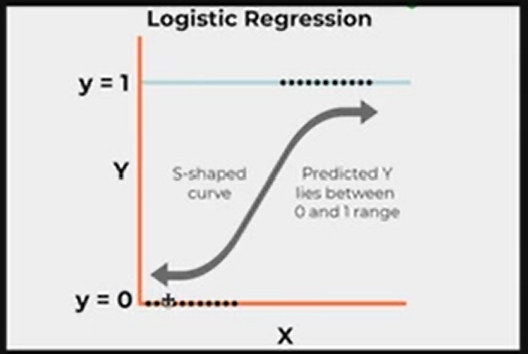

# Logistic Regression

Calculates the probability that an instance belongs to a certain class
(for this problem the probability a customer will churn)

* S-shaped curve with values between 0 - 1
* lower curve (closer to 0) = low probability of churn
* upper curve (closer to 1) = high probability of churn
* middle (steepest part of the curve) = small changes in input can lead to large predictability changes

*For this problem X moving to the right shows as Feature values increase the probability of churn also increases*

=> naturally limit output <br>
=> when the model makes a mistake while learning it will tweak its criteria slightly to get a better result <br>
=> will gradually learn which features are most important for comparing possibility of churn

> Learns to predict churn target value based on scalable features
> Used for new customer churn predictions (when we verify accuracy)
>> New Data => Log. Model => Return prediction value b/w 0-1

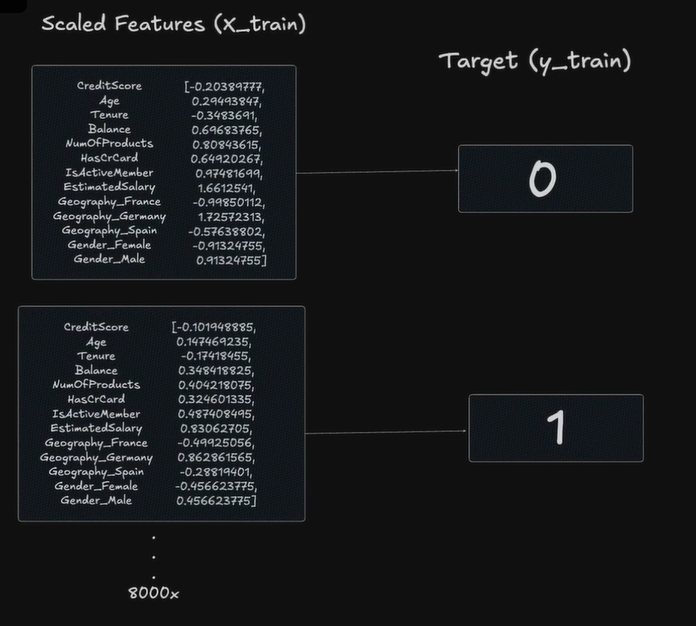

In [ ]:
# returns an array of predictions between 0-1
lr_predictions = lr_model.predict(X_test)

In [ ]:
lr_predictions

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# evaluate the performance by comparing prediction to the actual data
# use sklearn evaluate function (calculates the percentage of correct predications)
# accuracy_score(actual data, predicted data)
lr_accuracy = accuracy_score(y_test, lr_predictions)

In [ ]:
lr_accuracy

0.811

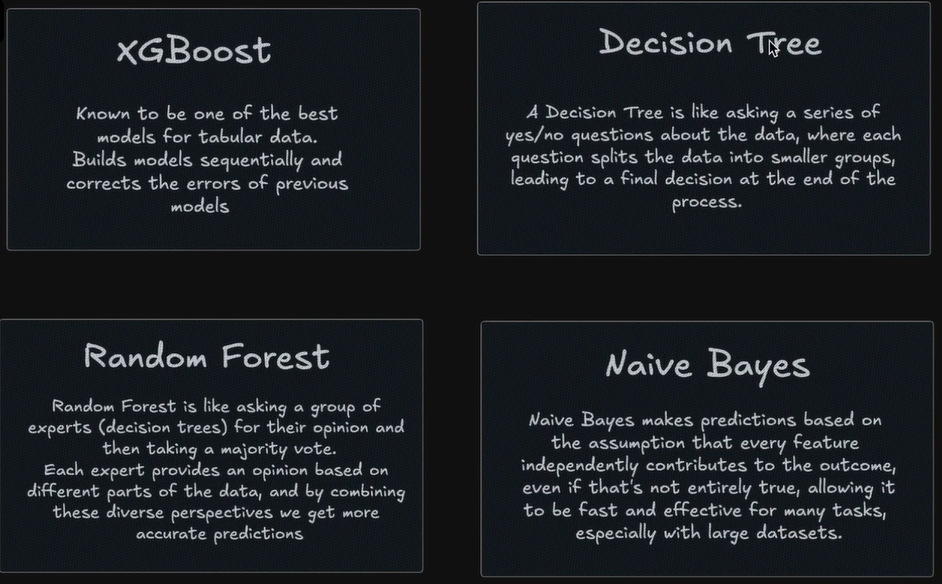

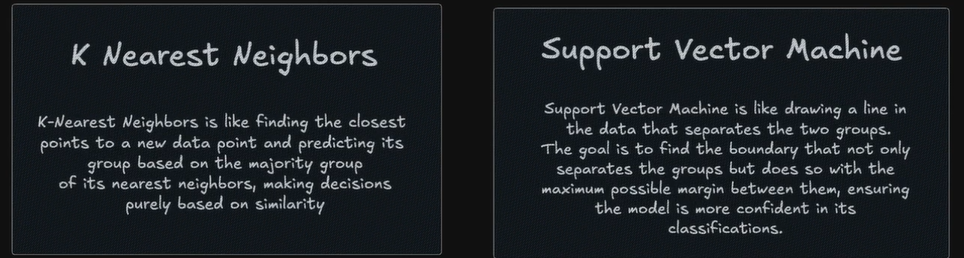

In [ ]:
# Add some simple code that allows us to
# train, evaluate and save multiple models
# allowing us to find the best performer for our problem

In [ ]:
def evaluate_and_save_model(model, X_train, X_test, y_train, y_test, filename):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"{model.__class__.__name__} Accuracy: {accuracy:.4f}")
  print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
  print("-----------NEXT-MODEL--------------")

# wb opens the file in binary mode so you can dumb the binary data in
  with open(filename, "wb") as file:
    pickle.dump(model, file)

  print(f"Model saved as {filename}")

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42)
# pkl is a pickle file
evaluate_and_save_model(xgb_model, X_train, X_test, y_train, y_test, "xgb_model.pkl")

gbc_model = GradientBoostingClassifier(random_state=42)
evaluate_and_save_model(gbc_model, X_train, X_test, y_train, y_test, "gbc_model.pkl")

dt_model = DecisionTreeClassifier(random_state=42)
evaluate_and_save_model(dt_model, X_train, X_test, y_train, y_test, "dt_model.pkl")

rf_model = RandomForestClassifier(random_state=42)
evaluate_and_save_model(rf_model, X_train, X_test, y_train, y_test, "rf_model.pkl")

# no random_state for GaussianNB or KNeighborsClassifier
nb_model = GaussianNB()
evaluate_and_save_model(nb_model, X_train, X_test, y_train, y_test, "nb_model.pkl")

knn_model = KNeighborsClassifier()
evaluate_and_save_model(knn_model, X_train, X_test, y_train, y_test, "knn_model.pkl")

svm_model = SVC(random_state=42)
evaluate_and_save_model(svm_model, X_train, X_test, y_train, y_test, "svm_model.pkl")


# StackingClassifier is required to have a list of estimators to stack
model_estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# no random_state for StackingClassifier()
stc_model = StackingClassifier(estimators=model_estimators)
evaluate_and_save_model(stc_model, X_train, X_test, y_train, y_test, "stc_model.pkl")


XGBClassifier Accuracy: 0.8625

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.71      0.51      0.59       393

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000

-----------NEXT-MODEL--------------
Model saved as xgb_model.pkl
GradientBoostingClassifier Accuracy: 0.8640

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

-----------NEXT-MODEL--------------
Model saved as gbc_model.pkl
DecisionTreeClassifier Accuracy: 0.7805

Classification Report:
              precision    re

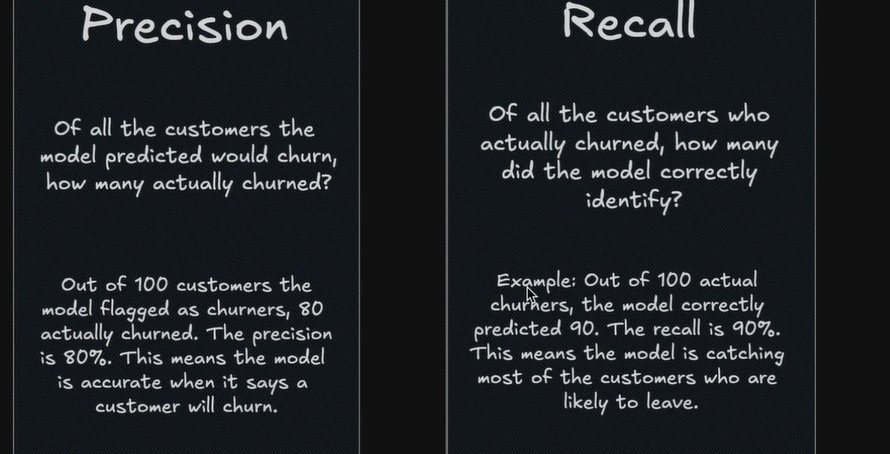

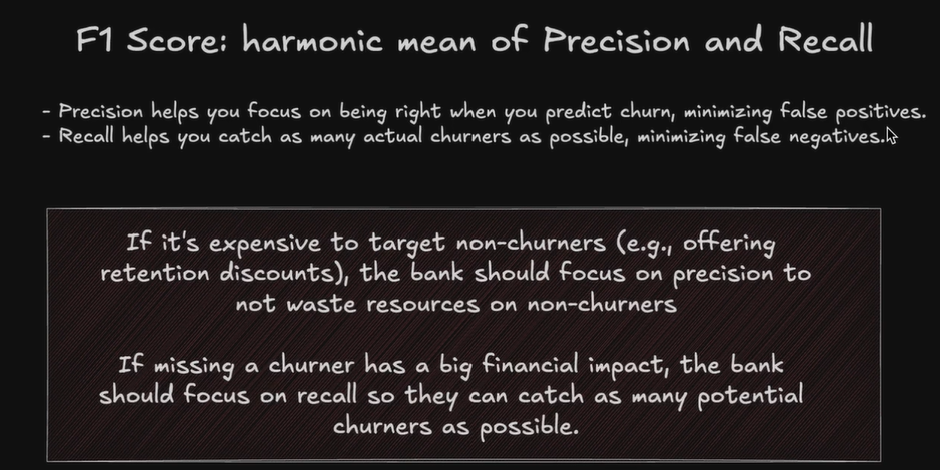

# Rank importance of each feature
Now we need to find which features correlate the most to customers who end up churning

In [ ]:
# extract feature importances and the name
feature_importances = xgb_model.feature_importances_
feature_names = features.columns

In [ ]:
feature_importances

array([0.03500515, 0.10955004, 0.03005428, 0.05278617, 0.32388842,
       0.03194036, 0.16414644, 0.03265523, 0.04646328, 0.09137332,
       0.0368547 , 0.04528258, 0.        ], dtype=float32)

In [ ]:
feature_names

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object')

In [ ]:
# create data frame to store feature name and their corresponding importances
feature_importances_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

In [ ]:
feature_importances_df

,feature,importance
0,CreditScore,0.035005
1,Age,0.109550
2,Tenure,0.030054
3,Balance,0.052786
4,NumOfProducts,0.323888
5,HasCrCard,0.031940
6,IsActiveMember,0.164146
7,EstimatedSalary,0.032655
8,Geography_France,0.046463
9,Geography_Germany,0.091373


In [ ]:
# sort column by most to least importance
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False)

In [ ]:
feature_importances_df

,feature,importance
4,NumOfProducts,0.323888
6,IsActiveMember,0.164146
1,Age,0.109550
9,Geography_Germany,0.091373
3,Balance,0.052786
8,Geography_France,0.046463
11,Gender_Female,0.045283
10,Geography_Spain,0.036855
0,CreditScore,0.035005
7,EstimatedSalary,0.032655


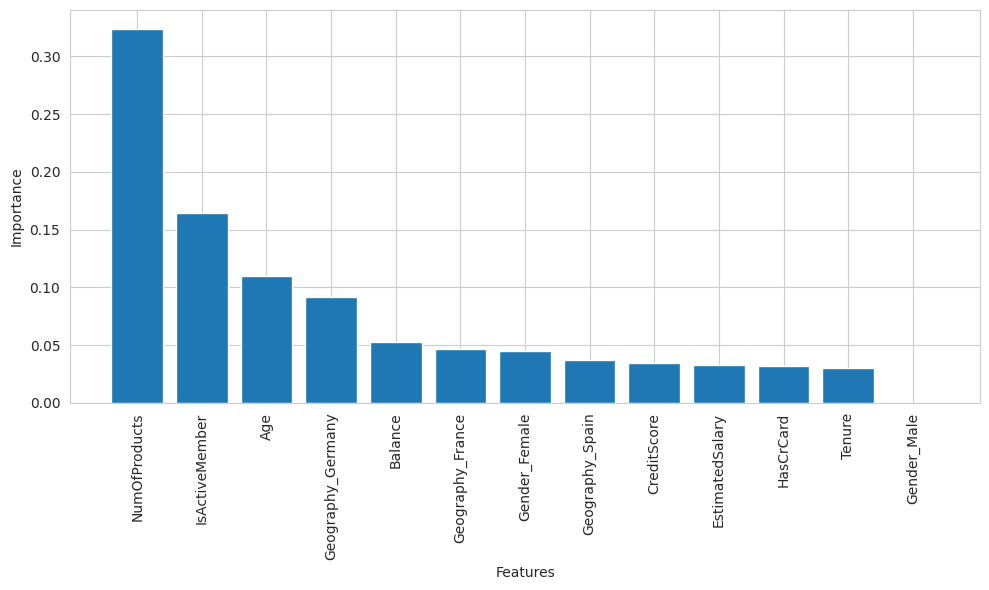

In [ ]:
# plot a bar chart to visualize the above data
plt.figure(figsize=(10, 6))
# bar(x-axis, y-axis)
plt.bar(feature_importances_df['feature'], feature_importances_df['importance'])
# rotating the ticks by 90 degrees makes the bar labels become vertical
#  if you don't rotate the ticks the labels overlap making them unreadable
# not necessary for labels that are smll numbers
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
# tight_layout decreases the amount of space taken up by the graph
plt.tight_layout()
plt.show()

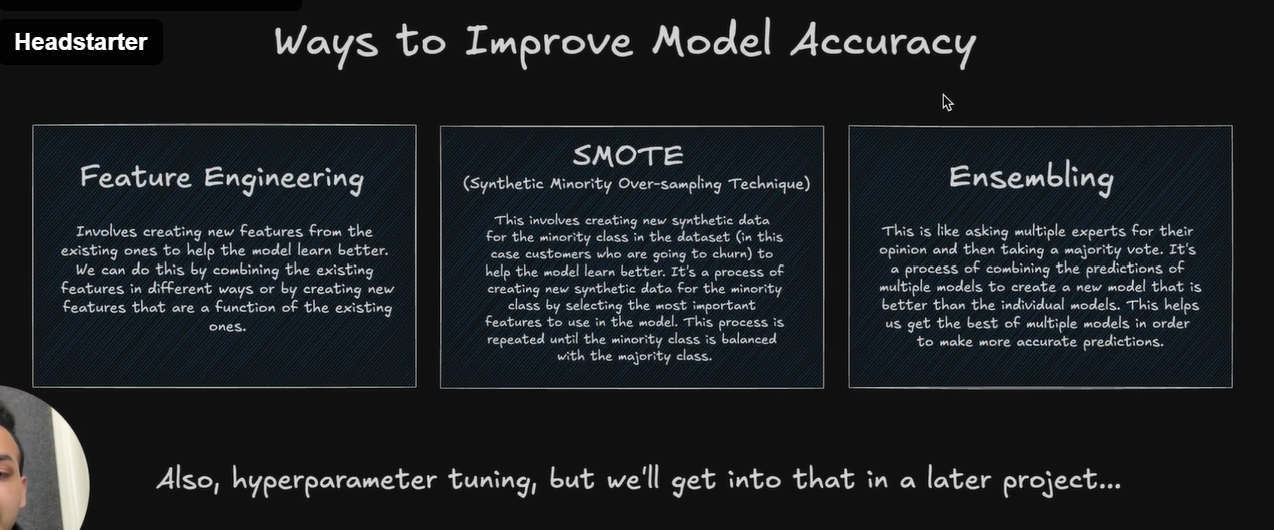

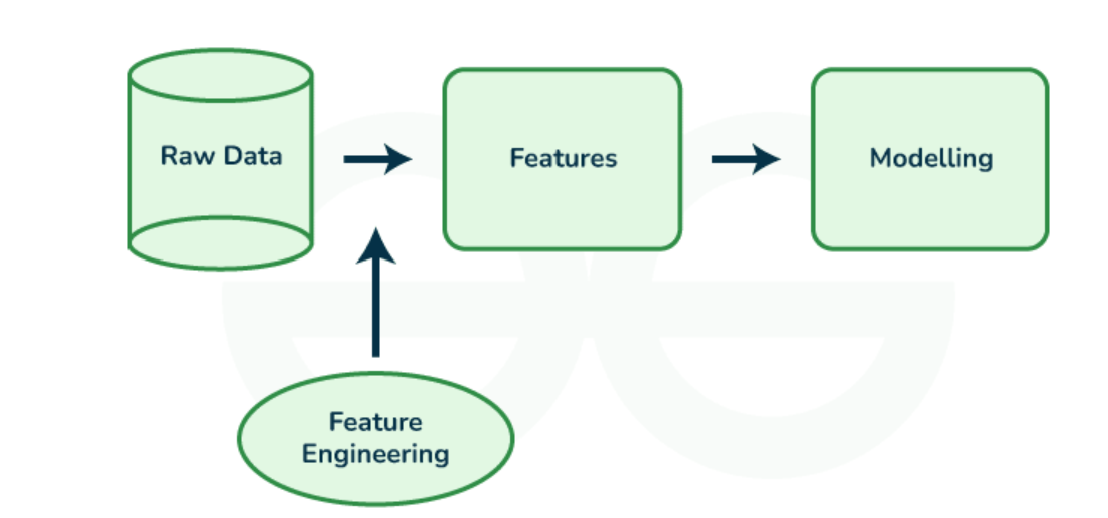

In [ ]:
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True


In [ ]:
# add column for customer lifetime value
features['CLV'] = df['Balance'] * df['EstimatedSalary']/100000
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CLV
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False,94319.527887
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False,181904.056115
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False,99259.102400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True,0.000000
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True,58344.761420
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False,0.000000
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True,69736.344344


In [ ]:
#  add column for age group
features["AgeGroup"] = pd.cut(df['Age'], bins=[0,30,45,60,100], labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])

In [ ]:
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CLV,AgeGroup
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False,0.000000,MiddleAge
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False,94319.527887,MiddleAge
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False,181904.056115,MiddleAge
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False,0.000000,MiddleAge
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False,99259.102400,MiddleAge
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True,0.000000,MiddleAge
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True,58344.761420,MiddleAge
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False,0.000000,MiddleAge
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True,69736.344344,MiddleAge


In [ ]:
# add column for ratio of customers age and tenure with the bank
features['TenureAgeRatio'] = df['Tenure'] / df['Age']

In [ ]:
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CLV,AgeGroup,TenureAgeRatio
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False,0.000000,MiddleAge,0.047619
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False,94319.527887,MiddleAge,0.024390
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False,181904.056115,MiddleAge,0.190476
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False,0.000000,MiddleAge,0.025641
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False,99259.102400,MiddleAge,0.046512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True,0.000000,MiddleAge,0.128205
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True,58344.761420,MiddleAge,0.285714
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False,0.000000,MiddleAge,0.194444
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True,69736.344344,MiddleAge,0.071429


In [ ]:
# handle categorical values by converting them to dummy (binary) values
# drop_first deletes the initial column for the new columns being created for each category
#  this keeps from having duplicate data
features = pd.get_dummies(features, drop_first=True)

In [ ]:
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CLV,TenureAgeRatio,AgeGroup_MiddleAge,AgeGroup_Senior,AgeGroup_Elderly
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False,0.000000,0.047619,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False,94319.527887,0.024390,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False,181904.056115,0.190476,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False,0.000000,0.025641,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False,99259.102400,0.046512,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,True,False,False,False,True,0.000000,0.128205,True,False,False
9996,516,35,10,57369.61,1,1,1,101699.77,True,False,False,False,True,58344.761420,0.285714,True,False,False
9997,709,36,7,0.00,1,0,1,42085.58,True,False,False,True,False,0.000000,0.194444,True,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,False,True,False,False,True,69736.344344,0.071429,True,False,False


In [ ]:
feature_names = features.columns
feature_names

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male',
       'CLV', 'TenureAgeRatio', 'AgeGroup_MiddleAge', 'AgeGroup_Senior',
       'AgeGroup_Elderly'],
      dtype='object')

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features,target, test_size=0.2, random_state=42)

In [ ]:
# create new instance of xgboost model with new features
xgboost_model = xgb.XGBClassifier(random_state=42)

evaluate_and_save_model(xgboost_model, X_train, X_test, y_train, y_test, "xgbost-featureEngineered.pkl")

XGBClassifier Accuracy: 0.8540

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1607
           1       0.67      0.50      0.58       393

    accuracy                           0.85      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.85      0.85      2000

-----------NEXT-MODEL--------------
Model saved as xgbost-featureEngineered.pkl


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
evaluate_and_save_model(xgboost_model, X_resampled, X_test, y_resampled, y_test, "xgboost-SMOTE.pkl")

XGBClassifier Accuracy: 0.8545

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1607
           1       0.65      0.55      0.60       393

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.85      0.85      0.85      2000

-----------NEXT-MODEL--------------
Model saved as xgboost-SMOTE.pkl


In [ ]:
# VotingClassifier combines the predictions of multiple models together
from sklearn.ensemble import VotingClassifier

In [ ]:
voting_clf = VotingClassifier(
    estimators=[('xgboost', xgb.XGBClassifier(random_state=42)),
     ('rf', RandomForestClassifier(random_state=42)),
                ('svm', SVC(random_state=42, probability=True))],
    voting='hard'
)

In [ ]:
evaluate_and_save_model(voting_clf, X_resampled, X_test, y_resampled, y_test, 'voting_clf.pkl')

VotingClassifier Accuracy: 0.8530

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1607
           1       0.63      0.59      0.61       393

    accuracy                           0.85      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.85      0.85      0.85      2000

-----------NEXT-MODEL--------------
Model saved as voting_clf.pkl
